# Exporting high quality visualizations

Apply final layout checks and save Matplotlib figures in editable PDF plus high-resolution PNG without embedding project paths.

All signals, labels, and coordinates in this notebook are deterministic and
synthetic. They do not represent a participant. Run cells from top to bottom.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow this notebook to run from JupyterLab or from the repository root.
HERE = Path.cwd()
EXAMPLES = HERE if (HERE / "_synthetic.py").exists() else HERE / "notebooks" / "examples"
sys.path.insert(0, str(EXAMPLES.resolve()))
REPOSITORY = EXAMPLES.parents[1]
if (REPOSITORY / "ERPy").exists():
    sys.path.insert(0, str(REPOSITORY.resolve()))

import ERPy as ep
import ERPy.viz as viz
from IPython.display import Image, display as show_output
from _synthetic import (
    make_detection_table,
    make_edges,
    make_electrode_metadata,
    make_epochs,
    make_metric_table,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

# The publication workflow stores PNGs so the figures render directly on GitHub.
get_ipython().run_line_magic("matplotlib", "inline")

def show_plotly_snapshot(figure):
    # Use figure.show() to interact locally; these PNGs also render on GitHub.
    import plotly.graph_objects as go
    preview = go.Figure(figure)
    preview.layout.sliders = ()
    preview.layout.updatemenus = ()
    preview.update_layout(
        legend={"orientation": "h", "y": -0.08, "x": 0.05},
        margin={"l": 30, "r": 100, "t": 65, "b": 70},
    )
    show_output(Image(preview.to_image(format="png", width=1000, height=650, scale=1)))

In [2]:
epochs = make_epochs()
detections = make_detection_table(epochs)

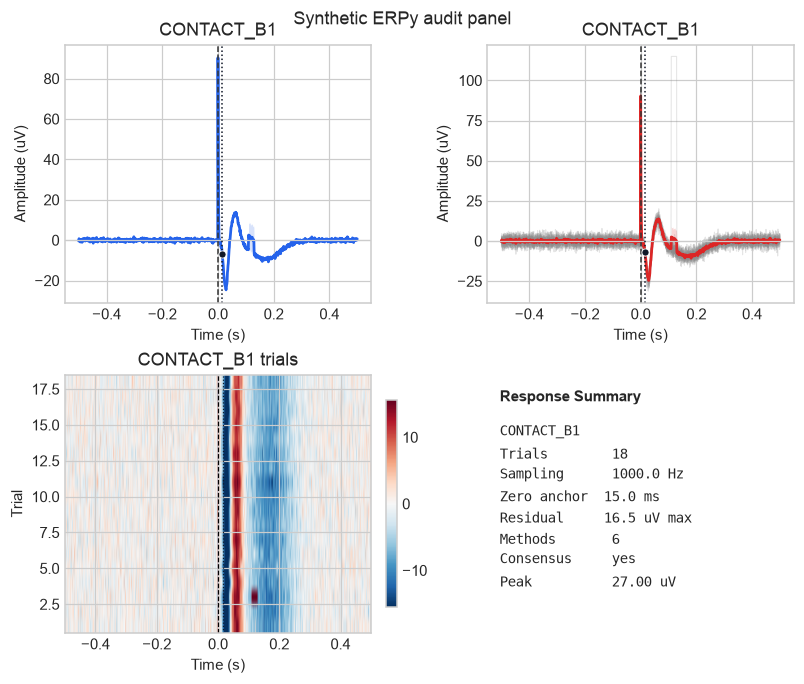

In [3]:
fig = viz.plot_summary_panel(epochs, "CONTACT_B1", detections=detections)
fig.set_size_inches(7.2, 6.0)
fig.suptitle("Synthetic ERPy audit panel", y=1.01)
fig.canvas.draw()
plt.show()

In [4]:
from tempfile import TemporaryDirectory

with TemporaryDirectory() as temporary_folder:
    paths = viz.save_analysis_figure(
        fig, "synthetic_audit_panel", patient_path=temporary_folder,
        formats=("png", "pdf")
    )
    print([Path(path).name for path in paths])

['synthetic_audit_panel.png', 'synthetic_audit_panel.pdf']


Before submission, inspect every file at the intended column width. Confirm
that labels, legends, panel letters, confidence bands, and color scales are
readable; keep at least 3 mm of quiet space around text; use vector PDF/SVG for
line art; and verify that PNGs are at least 300 dpi. Remove private identifiers
from visible content and file metadata, but retain a governed provenance record.

These export functions write to the path you provide and do not upload the
figure or its source data. An optional `ERPY-RR-<UUID>` release-record label is
an author-assigned local governance label, not a server address, and ERPy does
not create or register one automatically.